In [ ]:
!pip -q install huggingface_hub hf_transfer torch torchvision torchaudio pillow tqdm torchmetrics scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 71.4 MB/s eta 0:00:00


In [ ]:
import os
from huggingface_hub import hf_hub_download

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

DATASET_ID = "cj-mills/hagrid-sample-500k-384p"
ZIP_NAME = "hagrid-sample-500k-384p.zip"

zip_path = hf_hub_download(
    repo_id=DATASET_ID,
    filename=ZIP_NAME,
    repo_type="dataset",
    local_dir="/content/hagrid_zip",
    local_dir_use_symlinks=False,
)
print("Downloaded to:", zip_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


hagrid-sample-500k-384p.zip:   0%|          | 0.00/13.4G [00:00<?, ?B/s]

Downloaded to: /content/hagrid_zip/hagrid-sample-500k-384p.zip


In [ ]:
!mkdir -p /content/hagrid_500k
!unzip -q "/content/hagrid_zip/hagrid-sample-500k-384p.zip" -d /content/hagrid_500k
!ls /content/hagrid_500k/hagrid-sample-500k-384p | head -20

annotations_df.parquet
ann_train_val
hagrid_500k


In [ ]:
import pandas as pd
import os

DATA_ROOT = "/content/hagrid_500k/hagrid-sample-500k-384p"
df = pd.read_parquet(os.path.join(DATA_ROOT, "annotations_df.parquet"))

print("Columns:", df.columns.tolist())
print(df.head(2))

TARGET = ["ok" , "mute", "palm", "two_up", "two_up_inverted"]

df2 = df.reset_index(names="image_id")
df2 = df2[df2["labels"].apply(lambda xs: any(x in TARGET for x in xs))].reset_index(drop=True)

def explode_rows(df_in):
    rows = []
    for _, r in df_in.iterrows():
        image_id = r["image_id"]
        for bbox, label in zip(r["bboxes"], r["labels"]):
            if label in TARGET:
                rows.append({
                    "image_id": image_id,
                    "label": label,
                    "bbox": bbox,
                })
    return pd.DataFrame(rows)

samples_df = explode_rows(df2)
print(f"\nTotal crop samples: {len(samples_df)}")
print(samples_df["label"].value_counts())

Columns: ['bboxes', 'labels', 'leading_hand', 'leading_conf', 'user_id']
                                                                                 bboxes  \
00005c9c-3548-4a8f-9d0b-2dd4aff37fc9  [[0.23925175, 0.28595301, 0.25055143, 0.207776...   
0000738b-f640-448f-b697-a6b7d218f5db  [[0.3452406, 0.41348879, 0.16873308, 0.1271769...   

                                                  labels leading_hand  \
00005c9c-3548-4a8f-9d0b-2dd4aff37fc9              [call]        right   
0000738b-f640-448f-b697-a6b7d218f5db  [call, no_gesture]        right   

                                      leading_conf  \
00005c9c-3548-4a8f-9d0b-2dd4aff37fc9           1.0   
0000738b-f640-448f-b697-a6b7d218f5db           1.0   

                                                                                user_id  
00005c9c-3548-4a8f-9d0b-2dd4aff37fc9  5a389ffe1bed6660a59f4586c7d8fe2770785e5bf79b09...  
0000738b-f640-448f-b697-a6b7d218f5db  7bc2b8ae46e76c547837aae519fd5af0389eeeb59375c9...  


In [ ]:
import glob

all_imgs = glob.glob(os.path.join(DATA_ROOT, "**", "*.jpg"), recursive=True)
print("Total jpgs:", len(all_imgs))

img_map = {os.path.splitext(os.path.basename(p))[0]: p for p in all_imgs}

# Sanity check
ex_id = samples_df.iloc[0]["image_id"]
print("Example id:", ex_id)
print("Resolved path:", img_map.get(ex_id))

Total jpgs: 509323
Example id: 0000645d-0f12-49ce-b730-fa0213086ec8
Resolved path: /content/hagrid_500k/hagrid-sample-500k-384p/hagrid_500k/train_val_mute/0000645d-0f12-49ce-b730-fa0213086ec8.jpg


In [ ]:
ROTATION_MAP = {
    "two_up": {
        0:   "two_up",
        90:  "two_sideways",
        180: "two_down",
        270: "two_sideways",
    },
    "two_up_inverted": {
        0:   "two_up",
        90:  "two_sideways",
        180: "two_down",
        270: "two_sideways",
    },
}
PASSTHROUGH = {"ok" , "mute", "palm"}

new_rows = []
for _, r in samples_df.iterrows():
    label = r["label"]
    if label in PASSTHROUGH:
        new_rows.append({
            "image_id": r["image_id"],
            "bbox": r["bbox"],
            "label": label,
            "rotation": 0,
        })
    elif label in ROTATION_MAP:
        for angle, new_label in ROTATION_MAP[label].items():
            new_rows.append({
                "image_id": r["image_id"],
                "bbox": r["bbox"],
                "label": new_label,
                "rotation": angle,
            })

aug_df = pd.DataFrame(new_rows)
print(f"Augmented samples: {len(aug_df)}")
print(aug_df["label"].value_counts())

Augmented samples: 316956
label
two_sideways    115830
two_up           57915
two_down         57915
mute             28971
palm             28326
ok               27999
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    aug_df,
    test_size=0.1,
    random_state=42,
    stratify=aug_df["label"],
)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 285260 | Val: 31696


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

CLASSES = sorted(aug_df["label"].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print("Classes:", class_to_idx)

IMG_SIZE = 224

class HagridRotationDataset(Dataset):
    def __init__(self, df, img_map, class_to_idx, transform=None, pad=0.15):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.pad = pad

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        image_id = r["image_id"]
        label = r["label"]
        rotation = r["rotation"]
        x, y, w, h = r["bbox"]

        path = self.img_map[image_id]
        img_bgr = cv2.imread(path)
        H, W = img_bgr.shape[:2]

        # Normalized bbox -> pixels
        x1 = int(x * W);  y1 = int(y * H)
        x2 = int((x + w) * W);  y2 = int((y + h) * H)

        # Padding
        pad_px = int(self.pad * max(x2 - x1, y2 - y1))
        x1 = max(0, x1 - pad_px);  y1 = max(0, y1 - pad_px)
        x2 = min(W, x2 + pad_px);  y2 = min(H, y2 + pad_px)

        crop_bgr = img_bgr[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # Apply rotation (cv2.rotate is fast — no interpolation for 90 degree steps)
        if rotation == 90:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_90_CLOCKWISE)
        elif rotation == 180:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_180)
        elif rotation == 270:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_90_COUNTERCLOCKWISE)

        if self.transform is not None:
            x_t = self.transform(crop_rgb)
        else:
            x_t = torch.from_numpy(crop_rgb).permute(2, 0, 1).float() / 255.0

        y_t = self.class_to_idx[label]
        return x_t, y_t


train_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tfms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = HagridRotationDataset(train_df, img_map, class_to_idx, transform=train_tfms)
val_ds   = HagridRotationDataset(val_df,   img_map, class_to_idx, transform=val_tfms)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Classes: {'mute': 0, 'ok': 1, 'palm': 2, 'two_down': 3, 'two_sideways': 4, 'two_up': 5}
Train: 285260 | Val: 31696


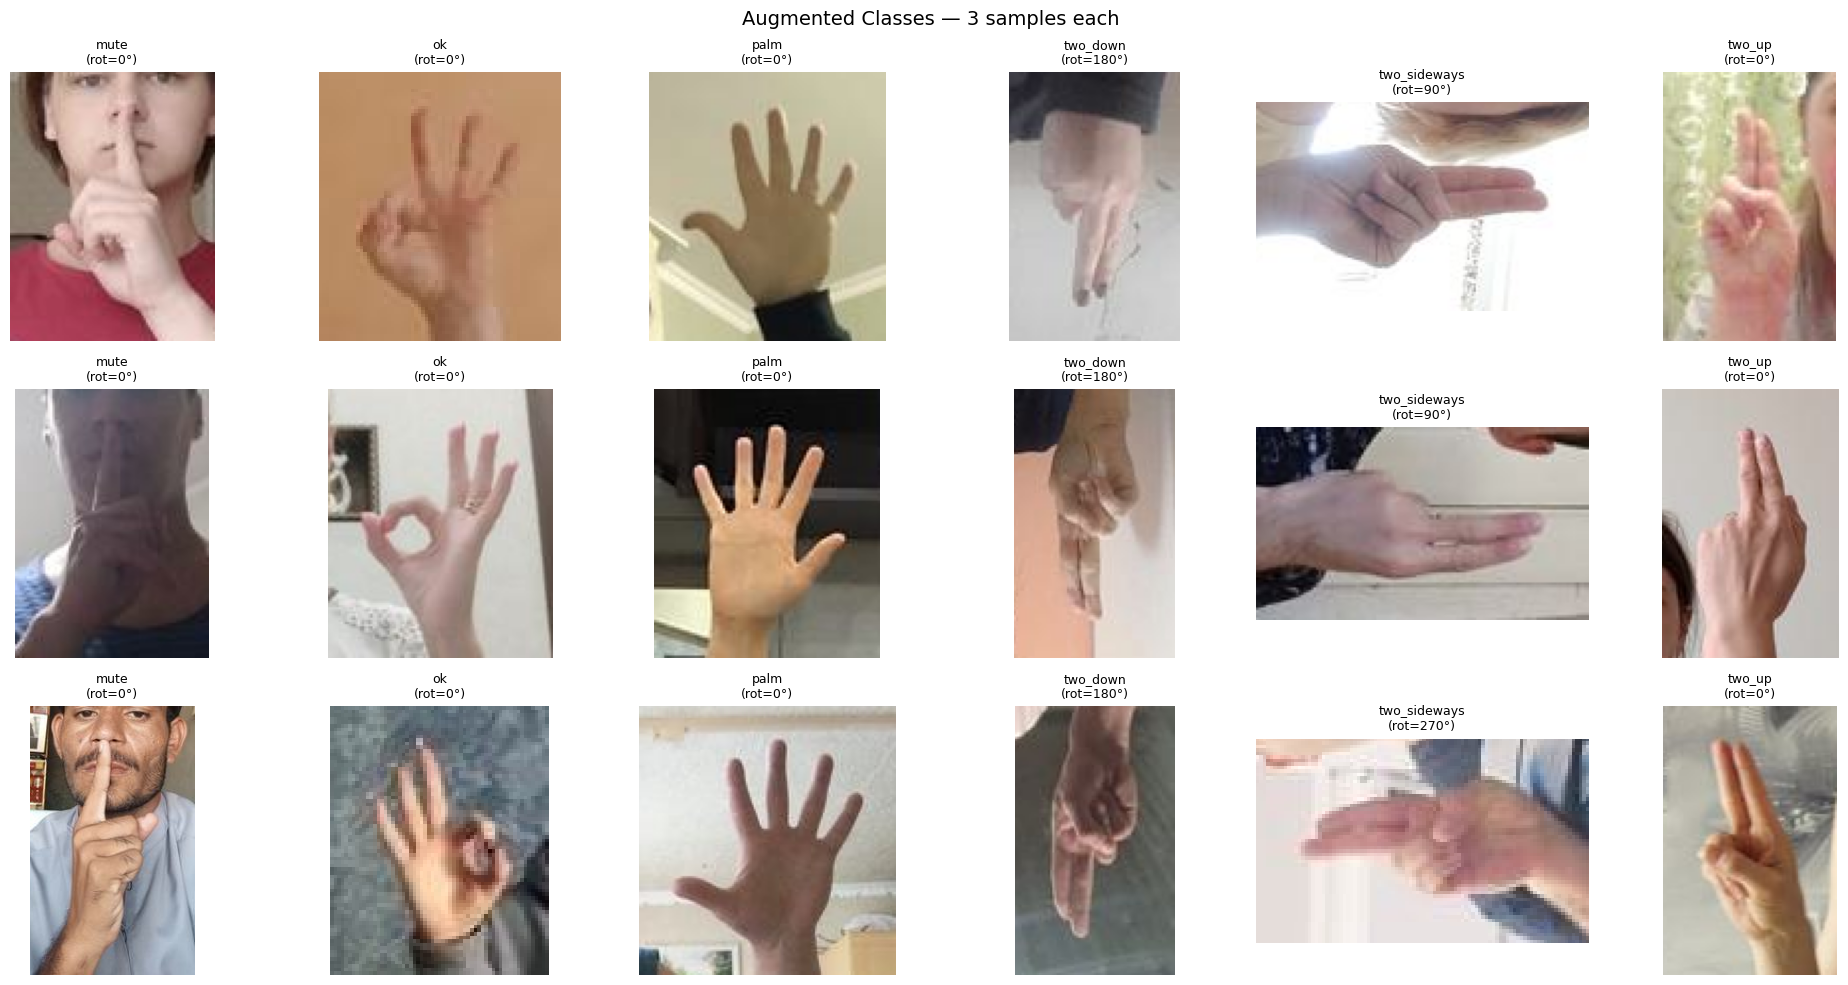

In [ ]:
# ============================================================
# Cell 7.5 — Visualize samples from each augmented class
# ============================================================
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(3, 6, figsize=(20, 10))

for col, cls_name in enumerate(CLASSES):
    # Get indices for this class from the training set
    cls_indices = train_df.index[train_df["label"] == cls_name].tolist()
    samples = random.sample(cls_indices, min(3, len(cls_indices)))

    for row, orig_idx in enumerate(samples):
        # Use the dataset __getitem__ so we see exactly what the model sees
        # (crop + rotation applied), but skip normalization for display
        r = train_df.loc[orig_idx]
        image_id = r["image_id"]
        rotation = r["rotation"]
        x, y, w, h = r["bbox"]

        path = img_map[image_id]
        img_bgr = cv2.imread(path)
        H, W = img_bgr.shape[:2]

        x1 = int(x * W);  y1 = int(y * H)
        x2 = int((x + w) * W);  y2 = int((y + h) * H)
        pad_px = int(0.15 * max(x2 - x1, y2 - y1))
        x1 = max(0, x1 - pad_px);  y1 = max(0, y1 - pad_px)
        x2 = min(W, x2 + pad_px);  y2 = min(H, y2 + pad_px)

        crop_rgb = cv2.cvtColor(img_bgr[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

        if rotation == 90:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_90_CLOCKWISE)
        elif rotation == 180:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_180)
        elif rotation == 270:
            crop_rgb = cv2.rotate(crop_rgb, cv2.ROTATE_90_COUNTERCLOCKWISE)

        axes[row][col].imshow(crop_rgb)
        axes[row][col].set_title(f"{cls_name}\n(rot={rotation}°)", fontsize=9)
        axes[row][col].axis("off")

fig.suptitle("Augmented Classes — 3 samples each", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from torchmetrics.classification import MulticlassAccuracy
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_CLASSES = len(CLASSES)

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

loss_fn = nn.CrossEntropyLoss()
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
acc_metric = MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)

NUM_EPOCHS = 10

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    acc_metric.reset()

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in tqdm(dl, leave=False):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = loss_fn(logits, y)

            if train:
                opt.zero_grad()
                loss.backward()
                opt.step()

            total_loss += loss.item() * x.size(0)
            acc_metric.update(logits.softmax(dim=1), y)

    return total_loss / len(dl.dataset), acc_metric.compute().item()

best_val_acc = 0.0
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_dl, train=True)
    va_loss, va_acc = run_epoch(val_dl,   train=False)
    print(f"Epoch {epoch}: train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "state_dict": model.state_dict(),
            "classes": CLASSES,
            "class_to_idx": class_to_idx,
            "idx_to_class": idx_to_class,
            "img_size": IMG_SIZE,
            "val_acc": va_acc,
        }, "/content/best_gesture_model.pth")
        print(f"  -> Saved best model (val_acc={va_acc:.3f})")

print(f"\nDone! Best val accuracy: {best_val_acc:.3f}")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


  0%|          | 0/4458 [00:00<?, ?it/s]

  0%|          | 0/496 [00:00<?, ?it/s]

Epoch 1: train loss 0.0134 acc 0.994 | val loss 0.0025 acc 0.999
  -> Saved best model (val_acc=0.999)


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7edf81da8540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7edf81da8540>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^ ^ ^ 

Epoch 3: train loss 0.0030 acc 0.999 | val loss 0.0035 acc 0.999


  0%|          | 0/4458 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7edf81da8540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7edf81da8540>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download("/content/best_gesture_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>